In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_theme(style="whitegrid", palette="deep")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def find_dataset(filename="heart.csv"):
    search_roots = ["/kaggle/input", "/content", "."]
    for root in search_roots:
        if os.path.exists(root):
            for dirname, _, filenames in os.walk(root):
                if filename in filenames:
                    return os.path.join(dirname, filename)
    return filename

DATA_PATH = find_dataset("heart.csv")
print(f" Dataset located at: {DATA_PATH}")

CONFIG = {
    "project_name": "Explainable Heart Disease Risk Prediction",
    "random_state": RANDOM_STATE,
    "test_size": 0.2,
    "cv_folds": 5,
    "data_path": DATA_PATH,
    "output_dir": "outputs/",
    "model_dir": "models/",
    "figures_dir": "outputs/figures/"
}

for path in [CONFIG["output_dir"], CONFIG["model_dir"], CONFIG["figures_dir"]]:
    os.makedirs(path, exist_ok=True)

print(f"✅ Project initialized: {CONFIG['project_name']}")
print(f" Run timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f" Random seed set to: {RANDOM_STATE}")

 Dataset located at: /kaggle/input/datasets/maleehariaz/heart-disease/heart.csv
✅ Project initialized: Explainable Heart Disease Risk Prediction
 Run timestamp: 2026-08-20 10:30:05
 Random seed set to: 42


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

df_raw = pd.read_csv(CONFIG["data_path"])

print("DATASET OVERVIEW")

print(f"Shape: {df_raw.shape[0]} patients × {df_raw.shape[1]} columns")
print(f"Missing values: {df_raw.isnull().sum().sum()}")
print(f"Duplicate rows: {df_raw.duplicated().sum()}")

FEATURE_DICT = {
    "age":      "Age in years",
    "sex":      "Sex (1 = male, 0 = female)",
    "cp":       "Chest pain type (0-3: typical angina, atypical, non-anginal, asymptomatic)",
    "trestbps": "Resting blood pressure (mm Hg)",
    "chol":     "Serum cholesterol (mg/dl)",
    "fbs":      "Fasting blood sugar > 120 mg/dl (1 = true)",
    "restecg":  "Resting ECG results (0-2)",
    "thalach":  "Maximum heart rate achieved",
    "exang":    "Exercise-induced angina (1 = yes)",
    "oldpeak":  "ST depression induced by exercise relative to rest",
    "slope":    "Slope of peak exercise ST segment (0-2)",
    "ca":       "Number of major vessels colored by fluoroscopy (0-4)",
    "thal":     "Thalassemia (0-3: normal, fixed defect, reversible defect)",
    "target":   "Presence of heart disease (1 = disease, 0 = no disease)"
}

n_before = df_raw.shape[0]
df = df_raw.drop_duplicates().reset_index(drop=True)
n_after = df.shape[0]
print(f"\n Duplicates removed: {n_before - n_after} ({n_before} → {n_after} unique patients)")
print("   (Common data leakage trap in this dataset — corrected here.)")

clinical_bounds = {
    "age": (0, 120), "trestbps": (60, 250), "chol": (0, 700),
    "thalach": (60, 250), "oldpeak": (0, 10)
}
print("\nClinical plausibility check:")
for col, (lo, hi) in clinical_bounds.items():
    out_of_range = df[(df[col] < lo) | (df[col] > hi)].shape[0]
    status = "✅ OK" if out_of_range == 0 else f" {out_of_range} rows flagged"
    print(f"  {col:10s}: {status}")

NUMERIC_FEATURES = ["age", "trestbps", "chol", "thalach", "oldpeak"]
CATEGORICAL_FEATURES = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal"]
TARGET = "target"

X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"\nFeature set: {X.shape[1]} features")
print(f"Class balance: {y.value_counts(normalize=True).round(3).to_dict()}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=CONFIG["test_size"],
    random_state=CONFIG["random_state"],
    stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} patients")
print(f"Test set:  {X_test.shape[0]} patients")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

df.to_csv(f"{CONFIG['output_dir']}heart_cleaned.csv", index=False)
joblib.dump(scaler, f"{CONFIG['model_dir']}heart_scaler.pkl")

print("\n✅ Preprocessing complete. Artifacts saved to outputs/ and models/")

DATASET OVERVIEW
Shape: 1025 patients × 14 columns
Missing values: 0
Duplicate rows: 723

 Duplicates removed: 723 (1025 → 302 unique patients)
   (Common data leakage trap in this dataset — corrected here.)

Clinical plausibility check:
  age       : ✅ OK
  trestbps  : ✅ OK
  chol      : ✅ OK
  thalach   : ✅ OK
  oldpeak   : ✅ OK

Feature set: 13 features
Class balance: {1: 0.543, 0: 0.457}

Train set: 241 patients
Test set:  61 patients

✅ Preprocessing complete. Artifacts saved to outputs/ and models/


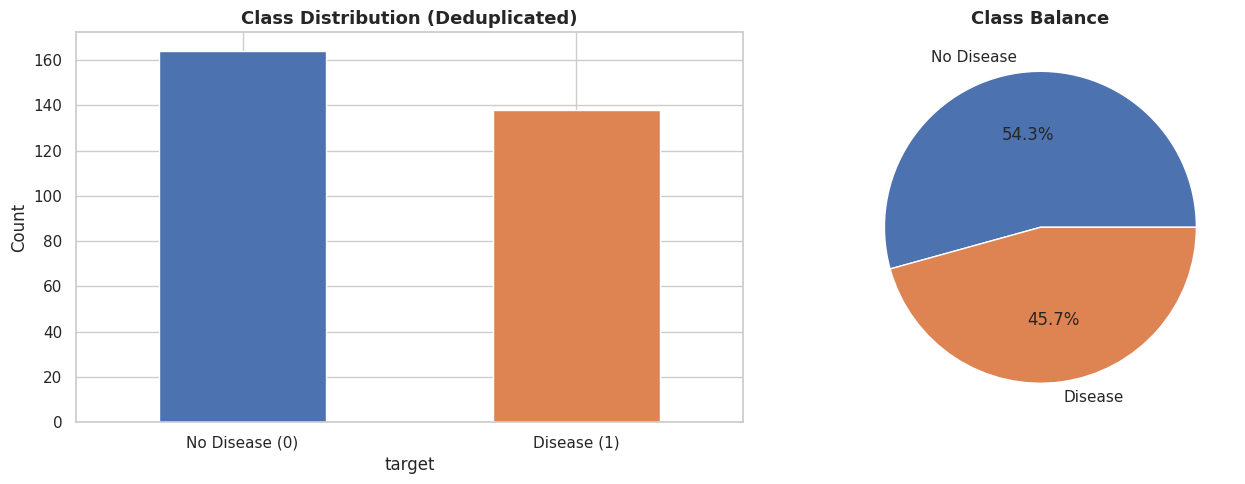

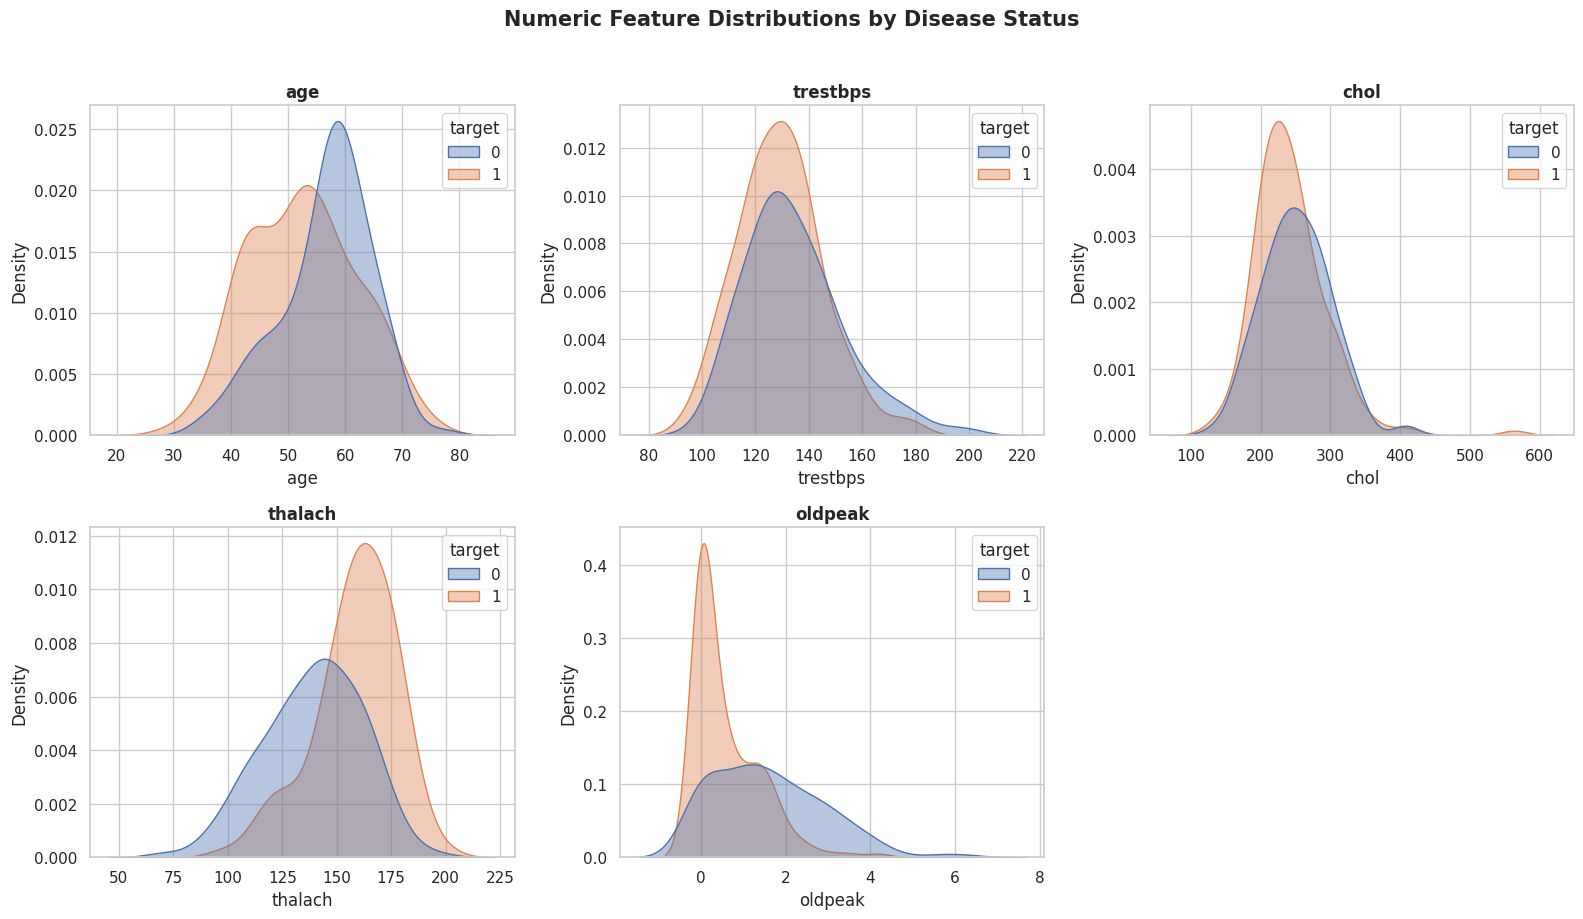



INDEPENDENT SAMPLES T-TEST: Numeric Features vs Disease Status


Feature       t-statistic      p-value   Significant?


age                 3.994       0.0001     ✅ p < 0.05
trestbps            2.529       0.0120     ✅ p < 0.05
chol                1.425       0.1553         ❌ n.s.
thalach            -7.904       0.0000     ✅ p < 0.05
oldpeak             7.902       0.0000     ✅ p < 0.05


CHI-SQUARE TEST OF INDEPENDENCE: Categorical Features vs Disease Status
Feature       chi2-statistic      p-value   Significant?
sex                   23.084       0.0000     ✅ p < 0.05
cp                    80.979       0.0000     ✅ p < 0.05
fbs                    0.092       0.7611         ❌ n.s.
restecg                9.730       0.0077     ✅ p < 0.05
exang                 55.456       0.0000     ✅ p < 0.05
slope                 46.889       0.0000     ✅ p < 0.05
ca                    73.690       0.0000     ✅ p < 0.05
thal                  84.610       0.0000     ✅ p < 0.05
ONE-WAY ANOVA: Max H

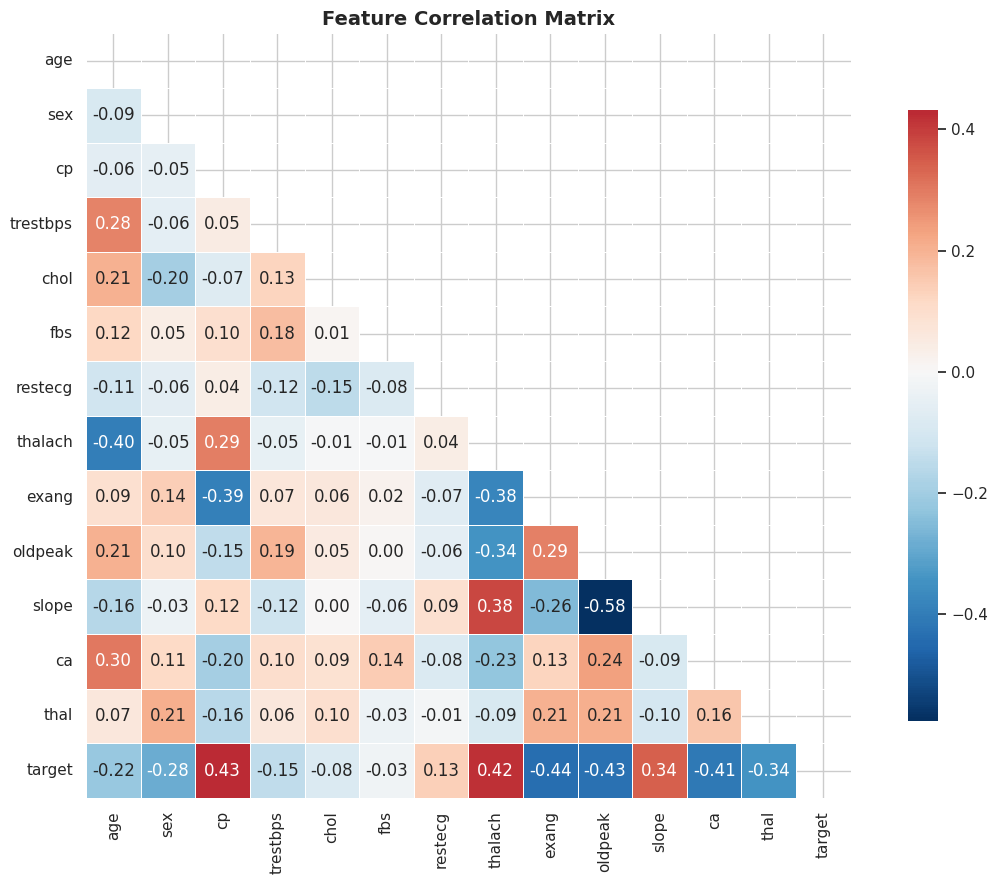


✅ EDA + statistical validation complete. Results saved to outputs/

Statistically significant numeric predictors (p<0.05): ['age', 'trestbps', 'thalach', 'oldpeak']
Statistically significant categorical predictors (p<0.05): ['sex', 'cp', 'restecg', 'exang', 'slope', 'ca', 'thal']


In [4]:
from scipy import stats

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df[TARGET].value_counts().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title("Class Distribution (Deduplicated)", fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)
axes[0].set_ylabel("Count")

df[TARGET].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                 colors=['#4C72B0', '#DD8452'],
                                 labels=['No Disease', 'Disease'])
axes[1].set_title("Class Balance", fontsize=13, fontweight='bold')
axes[1].set_ylabel("")
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}class_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(NUMERIC_FEATURES):
    sns.kdeplot(data=df, x=col, hue=TARGET, fill=True, alpha=0.4, ax=axes[i],
                palette=['#4C72B0', '#DD8452'])
    axes[i].set_title(f"{col}", fontweight='bold')
axes[-1].axis('off')
plt.suptitle("Numeric Feature Distributions by Disease Status", fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}numeric_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n")
print("INDEPENDENT SAMPLES T-TEST: Numeric Features vs Disease Status")
print("\n")
print(f"{'Feature':<12} {'t-statistic':>12} {'p-value':>12} {'Significant?':>14}")
print("\n")

ttest_results = []
for col in NUMERIC_FEATURES:
    group0 = df[df[TARGET] == 0][col]
    group1 = df[df[TARGET] == 1][col]
    t_stat, p_val = stats.ttest_ind(group0, group1, equal_var=False)
    sig = "✅ p < 0.05" if p_val < 0.05 else "❌ n.s."
    ttest_results.append({"feature": col, "t_stat": t_stat, "p_value": p_val, "significant": p_val < 0.05})
    print(f"{col:<12} {t_stat:>12.3f} {p_val:>12.4f} {sig:>14}")

ttest_df = pd.DataFrame(ttest_results)

print("\n")
print("CHI-SQUARE TEST OF INDEPENDENCE: Categorical Features vs Disease Status")
print(f"{'Feature':<12} {'chi2-statistic':>15} {'p-value':>12} {'Significant?':>14}")

chi2_results = []
for col in CATEGORICAL_FEATURES:
    contingency = pd.crosstab(df[col], df[TARGET])
    chi2, p_val, dof, expected = stats.chi2_contingency(contingency)
    sig = "✅ p < 0.05" if p_val < 0.05 else "❌ n.s."
    chi2_results.append({"feature": col, "chi2": chi2, "p_value": p_val, "significant": p_val < 0.05})
    print(f"{col:<12} {chi2:>15.3f} {p_val:>12.4f} {sig:>14}")

chi2_df = pd.DataFrame(chi2_results)

print("ONE-WAY ANOVA: Max Heart Rate (thalach) across Chest Pain Types (cp)")
print("\n")
groups = [df[df['cp'] == cp_val]['thalach'].values for cp_val in sorted(df['cp'].unique())]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}   p-value: {p_val:.4f}")
print("✅ Significant" if p_val < 0.05 else "❌ Not significant",
      "— max heart rate differs meaningfully across chest pain types" if p_val < 0.05 else "")

plt.figure(figsize=(12, 9))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Feature Correlation Matrix", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

ttest_df.to_csv(f"{CONFIG['output_dir']}ttest_results.csv", index=False)
chi2_df.to_csv(f"{CONFIG['output_dir']}chi2_results.csv", index=False)

print("\n✅ EDA + statistical validation complete. Results saved to outputs/")
print(f"\nStatistically significant numeric predictors (p<0.05): "
      f"{ttest_df[ttest_df['significant']]['feature'].tolist()}")
print(f"Statistically significant categorical predictors (p<0.05): "
      f"{chi2_df[chi2_df['significant']]['feature'].tolist()}")

✅ Engineered features added:
  - age_thalach_ratio: age relative to max heart rate achieved
  - hr_reserve: deviation from age-predicted max heart rate
  - stress_risk_score: weighted composite of exercise-stress indicators
  - high_risk_cp: binary flag for highest-risk chest pain category


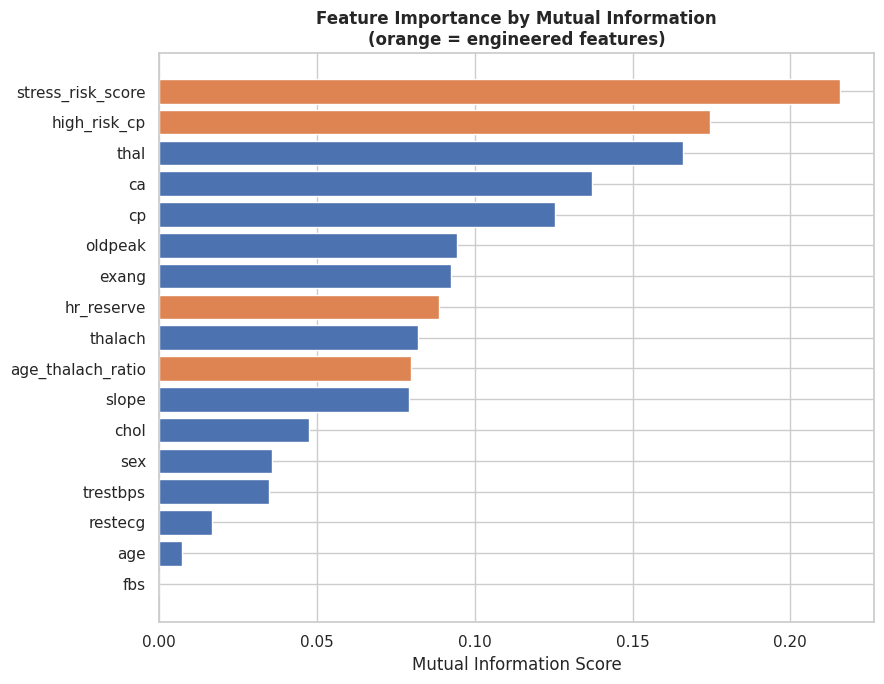


Top 5 features by mutual information:
          feature  mutual_info
stress_risk_score     0.215731
     high_risk_cp     0.174704
             thal     0.166047
               ca     0.137304
               cp     0.125284

Before SMOTE — train class balance: {1: 131, 0: 110}
After SMOTE  — train class balance: {1: 131, 0: 131}
Training set size: 241 → 262 (synthetic minority samples added)

✅ Feature engineering + SMOTE complete. Ready for model training.


In [5]:
from imblearn.over_sampling import SMOTE
from sklearn.feature_selection import mutual_info_classif

df_fe = df.copy()


df_fe["age_thalach_ratio"] = df_fe["age"] / df_fe["thalach"]

df_fe["hr_reserve"] = (220 - df_fe["age"]) - df_fe["thalach"]

df_fe["stress_risk_score"] = (
    df_fe["oldpeak"] * 0.4 +
    df_fe["exang"] * 0.3 +
    df_fe["ca"] * 0.3
)

df_fe["high_risk_cp"] = (df_fe["cp"] == 0).astype(int)  

print("✅ Engineered features added:")
print("  - age_thalach_ratio: age relative to max heart rate achieved")
print("  - hr_reserve: deviation from age-predicted max heart rate")
print("  - stress_risk_score: weighted composite of exercise-stress indicators")
print("  - high_risk_cp: binary flag for highest-risk chest pain category")

NEW_FEATURES = ["age_thalach_ratio", "hr_reserve", "stress_risk_score", "high_risk_cp"]
ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES + NEW_FEATURES

X_fe = df_fe.drop(columns=[TARGET])
y_fe = df_fe[TARGET]

mi_scores = mutual_info_classif(X_fe, y_fe, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": X_fe.columns, "mutual_info": mi_scores}).sort_values(
    "mutual_info", ascending=False).reset_index(drop=True)

plt.figure(figsize=(9, 7))
colors = ['#DD8452' if f in NEW_FEATURES else '#4C72B0' for f in mi_df["feature"]]
plt.barh(mi_df["feature"], mi_df["mutual_info"], color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Mutual Information Score")
plt.title("Feature Importance by Mutual Information\n(orange = engineered features)",
          fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}mutual_info_ranking.png", dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 5 features by mutual information:")
print(mi_df.head(5).to_string(index=False))

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=CONFIG["test_size"], random_state=RANDOM_STATE, stratify=y_fe
)

print(f"\nBefore SMOTE — train class balance: {y_train_fe.value_counts().to_dict()}")

smote = SMOTE(random_state=RANDOM_STATE)
X_train_smote, y_train_smote = smote.fit_resample(X_train_fe, y_train_fe)

print(f"After SMOTE  — train class balance: {y_train_smote.value_counts().to_dict()}")
print(f"Training set size: {X_train_fe.shape[0]} → {X_train_smote.shape[0]} (synthetic minority samples added)")

scaler_fe = StandardScaler()
numeric_and_engineered = NUMERIC_FEATURES + ["age_thalach_ratio", "hr_reserve", "stress_risk_score"]

X_train_smote_scaled = X_train_smote.copy()
X_test_fe_scaled = X_test_fe.copy()
X_train_smote_scaled[numeric_and_engineered] = scaler_fe.fit_transform(X_train_smote[numeric_and_engineered])
X_test_fe_scaled[numeric_and_engineered] = scaler_fe.transform(X_test_fe[numeric_and_engineered])

joblib.dump(scaler_fe, f"{CONFIG['model_dir']}heart_scaler_fe.pkl")
X_train_smote_scaled.to_csv(f"{CONFIG['output_dir']}X_train_smote.csv", index=False)
y_train_smote.to_csv(f"{CONFIG['output_dir']}y_train_smote.csv", index=False)
X_test_fe_scaled.to_csv(f"{CONFIG['output_dir']}X_test_fe.csv", index=False)
y_test_fe.to_csv(f"{CONFIG['output_dir']}y_test_fe.csv", index=False)
mi_df.to_csv(f"{CONFIG['output_dir']}mutual_info_scores.csv", index=False)

print("\n✅ Feature engineering + SMOTE complete. Ready for model training.")

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import (StratifiedKFold, RepeatedStratifiedKFold,
                                       GridSearchCV, cross_validate)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

X_train_final = X_train_smote_scaled
y_train_final = y_train_smote
X_test_final = X_test_fe_scaled
y_test_final = y_test_fe

param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(random_state=RANDOM_STATE, max_iter=2000),
        "params": {"C": [0.01, 0.1, 1, 10], "penalty": ["l2"], "solver": ["lbfgs"]}
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=RANDOM_STATE),
        "params": {"n_estimators": [100, 200, 300], "max_depth": [3, 5, 8, None],
                   "min_samples_leaf": [1, 2, 4]}
    },
    "SVM (RBF)": {
        "model": SVC(random_state=RANDOM_STATE, probability=True, kernel="rbf"),
        "params": {"C": [0.1, 1, 10], "gamma": ["scale", "auto", 0.01, 0.1]}
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss"),
        "params": {"n_estimators": [100, 200], "max_depth": [3, 4, 5],
                   "learning_rate": [0.01, 0.1, 0.2]}
    }
}

inner_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
best_estimators = {}

print("\n")
print("HYPERPARAMETER TUNING (GridSearchCV, inner 5-fold CV, optimizing F1)")
print("\n")

for name, spec in param_grids.items():
    grid = GridSearchCV(spec["model"], spec["params"], cv=inner_cv, scoring="f1", n_jobs=-1)
    grid.fit(X_train_final, y_train_final)
    best_estimators[name] = grid.best_estimator_
    print(f"\n {name}")
    print(f"   Best params: {grid.best_params_}")
    print(f"   Best inner-CV F1: {grid.best_score_:.4f}")


outer_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=RANDOM_STATE)
scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall",
           "f1": "f1", "roc_auc": "roc_auc"}

print("\n")
print("REPEATED STRATIFIED 5-FOLD CV (10 repeats = 50 total folds) ON TUNED MODELS")
print("\n")

cv_summary, raw_f1_scores = [], {}

for name, model in best_estimators.items():
    cv_results = cross_validate(model, X_train_final, y_train_final, cv=outer_cv,
                                  scoring=scoring, n_jobs=-1)
    raw_f1_scores[name] = cv_results["test_f1"]

    row = {"model": name}
    print(f"\n {name}  (n=50 folds)")
    for metric in scoring:
        scores = cv_results[f"test_{metric}"]
        mean, se = scores.mean(), scores.std() / np.sqrt(len(scores))
        ci95 = 1.96 * se
        row[metric] = mean
        row[f"{metric}_ci95"] = ci95
        print(f"   {metric:10s}: {mean:.4f}  (95% CI: ±{ci95:.4f})")
    cv_summary.append(row)

cv_summary_df = pd.DataFrame(cv_summary).sort_values("f1", ascending=False).reset_index(drop=True)


top2 = cv_summary_df["model"].iloc[:2].tolist()
scores_a, scores_b = raw_f1_scores[top2[0]], raw_f1_scores[top2[1]]
t_stat, p_val = stats.ttest_rel(scores_a, scores_b)

print("\n")
print(f"PAIRED T-TEST: {top2[0]} vs {top2[1]} (F1 scores across 50 folds)")
print("\n")
print(f"t-statistic: {t_stat:.3f}   p-value: {p_val:.4f}")
if p_val < 0.05:
    print(f"✅ {top2[0]} is statistically significantly better than {top2[1]} (p<0.05)")
else:
    print(f"❌ No statistically significant difference between {top2[0]} and {top2[1]} — "
          f"the CV ranking may not be reliable given this dataset size.")


best_model_name = cv_summary_df.iloc[0]["model"]
best_model = best_estimators[best_model_name]
best_model.fit(X_train_final, y_train_final)

y_pred_test = best_model.predict(X_test_final)
y_proba_test = best_model.predict_proba(X_test_final)[:, 1]

test_metrics = {
    "accuracy": accuracy_score(y_test_final, y_pred_test),
    "precision": precision_score(y_test_final, y_pred_test),
    "recall": recall_score(y_test_final, y_pred_test),
    "f1": f1_score(y_test_final, y_pred_test),
    "roc_auc": roc_auc_score(y_test_final, y_proba_test)
}

print("\n")
print(f" Best model: {best_model_name}")
print(f" Held-out test set (n=61, never used in tuning/CV):")
print("\n")
for k, v in test_metrics.items():
    print(f"   {k:10s}: {v:.4f}")

print(f"\n Note: with only 61 test patients, this single-split test estimate has real")
print(f"   sampling uncertainty (~±10% at 95% CI for a proportion this size).")
print(f"   The repeated CV results above are the more statistically reliable estimate")
print(f"   of true generalization performance: F1 = {cv_summary_df.iloc[0]['f1']:.4f} "
      f"± {cv_summary_df.iloc[0]['f1_ci95']:.4f}")

cv_summary_df.to_csv(f"{CONFIG['output_dir']}cv_model_comparison.csv", index=False)
for name, model in best_estimators.items():
    joblib.dump(model, f"{CONFIG['model_dir']}{name.replace(' ', '_').replace('(', '').replace(')', '')}.pkl")

trained_models = best_estimators
print("\n✅ Tuned models trained, statistically validated, and saved.")



HYPERPARAMETER TUNING (GridSearchCV, inner 5-fold CV, optimizing F1)



 Logistic Regression
   Best params: {'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}
   Best inner-CV F1: 0.8622

 Random Forest
   Best params: {'max_depth': 5, 'min_samples_leaf': 2, 'n_estimators': 100}
   Best inner-CV F1: 0.8470

 SVM (RBF)
   Best params: {'C': 10, 'gamma': 0.01}
   Best inner-CV F1: 0.8598

 XGBoost
   Best params: {'learning_rate': 0.2, 'max_depth': 4, 'n_estimators': 200}
   Best inner-CV F1: 0.8515


REPEATED STRATIFIED 5-FOLD CV (10 repeats = 50 total folds) ON TUNED MODELS



 Logistic Regression  (n=50 folds)
   accuracy  : 0.8404  (95% CI: ±0.0116)
   precision : 0.8212  (95% CI: ±0.0135)
   recall    : 0.8747  (95% CI: ±0.0185)
   f1        : 0.8452  (95% CI: ±0.0116)
   roc_auc   : 0.9111  (95% CI: ±0.0086)

 Random Forest  (n=50 folds)
   accuracy  : 0.8351  (95% CI: ±0.0131)
   precision : 0.8172  (95% CI: ±0.0141)
   recall    : 0.8674  (95% CI: ±0.0220)
   f1        : 0.8393  (95

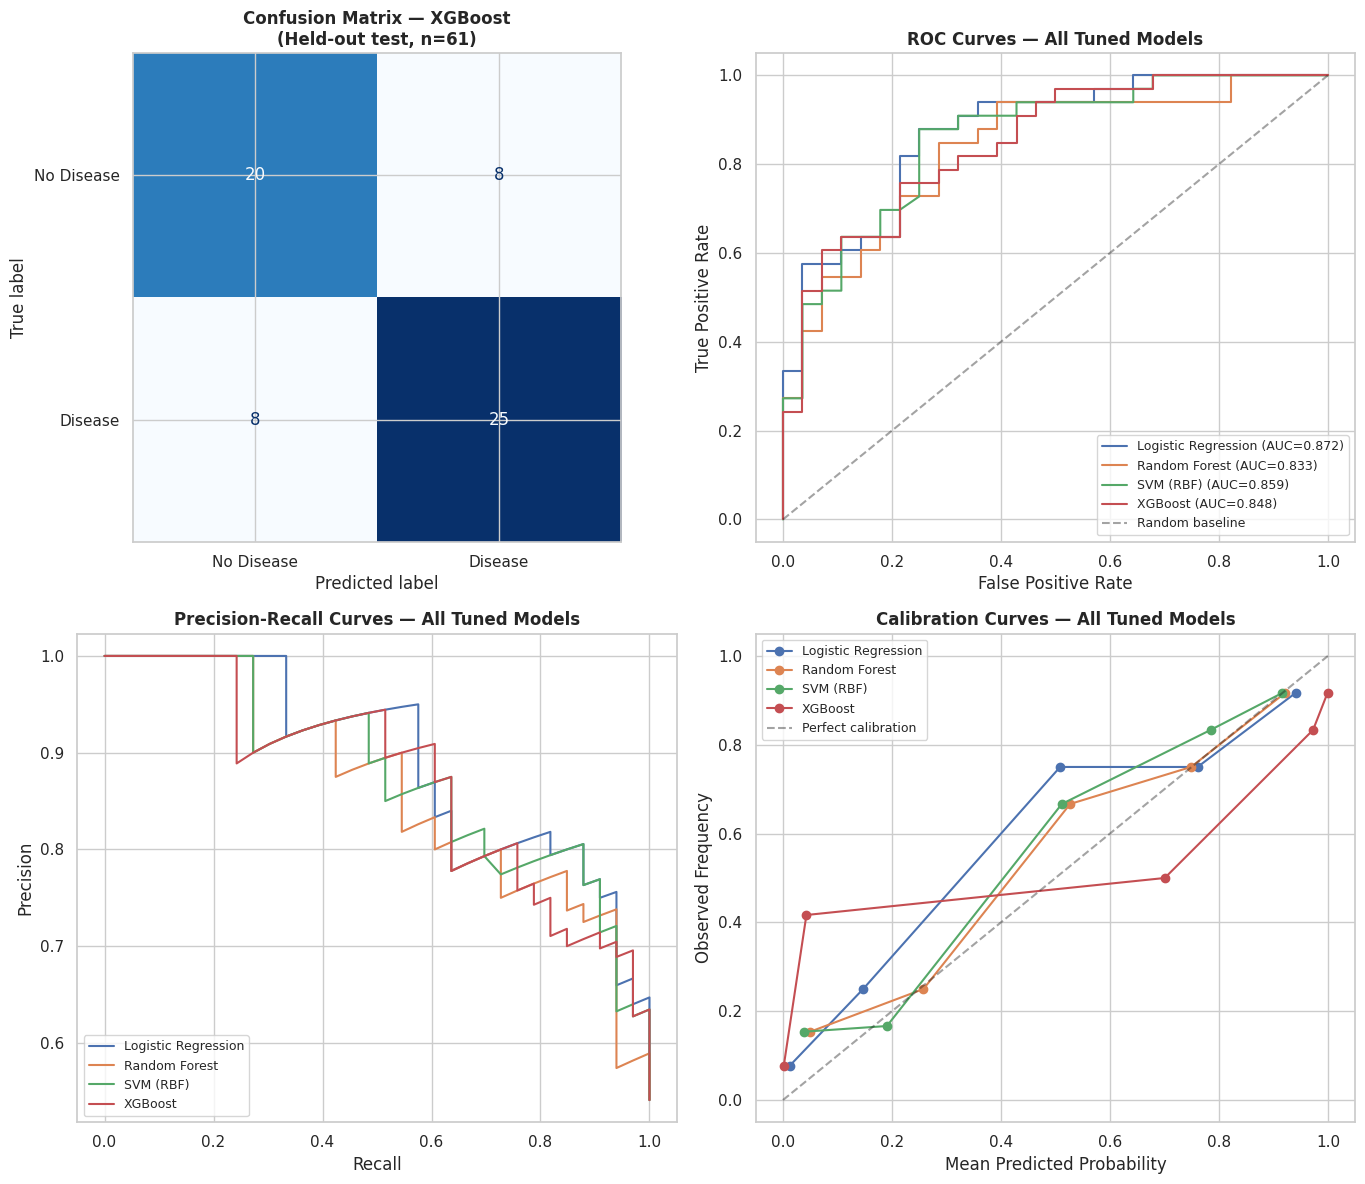



CLASSIFICATION REPORT — XGBoost (Held-out test set)


              precision    recall  f1-score   support

  No Disease       0.71      0.71      0.71        28
     Disease       0.76      0.76      0.76        33

    accuracy                           0.74        61
   macro avg       0.74      0.74      0.74        61
weighted avg       0.74      0.74      0.74        61

CLINICAL INTERPRETATION:
  True Negatives  (correctly cleared):        20
  False Positives (unnecessary follow-up):     8
  False Negatives (MISSED disease — critical): 8
  True Positives  (correctly flagged):         25

  Sensitivity (recall for disease): 0.758 — proportion of actual disease cases correctly identified
  Specificity: 0.714 — proportion of healthy patients correctly cleared

  In a clinical screening context, False Negatives (missed disease) are the
     costliest error type — they carry higher clinical risk than False Positives.


In [7]:
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                              precision_recall_curve, classification_report)
from sklearn.calibration import calibration_curve

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

cm = confusion_matrix(y_test_final, y_pred_test)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Disease", "Disease"])
disp.plot(ax=axes[0, 0], cmap="Blues", colorbar=False)
axes[0, 0].set_title(f"Confusion Matrix — {best_model_name}\n(Held-out test, n=61)", fontweight='bold')

for name, model in best_estimators.items():
    proba = model.predict_proba(X_test_final)[:, 1]
    fpr, tpr, _ = roc_curve(y_test_final, proba)
    auc = roc_auc_score(y_test_final, proba)
    axes[0, 1].plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
axes[0, 1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Random baseline")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate")
axes[0, 1].set_title("ROC Curves — All Tuned Models", fontweight='bold')
axes[0, 1].legend(loc='lower right', fontsize=9)

for name, model in best_estimators.items():
    proba = model.predict_proba(X_test_final)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test_final, proba)
    axes[1, 0].plot(rec, prec, label=name)
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].set_title("Precision-Recall Curves — All Tuned Models", fontweight='bold')
axes[1, 0].legend(loc='lower left', fontsize=9)

for name, model in best_estimators.items():
    proba = model.predict_proba(X_test_final)[:, 1]
    frac_pos, mean_pred = calibration_curve(y_test_final, proba, n_bins=5, strategy='quantile')
    axes[1, 1].plot(mean_pred, frac_pos, marker='o', label=name)
axes[1, 1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label="Perfect calibration")
axes[1, 1].set_xlabel("Mean Predicted Probability")
axes[1, 1].set_ylabel("Observed Frequency")
axes[1, 1].set_title("Calibration Curves — All Tuned Models", fontweight='bold')
axes[1, 1].legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}detailed_evaluation.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n")
print(f"CLASSIFICATION REPORT — {best_model_name} (Held-out test set)")
print("\n")
print(classification_report(y_test_final, y_pred_test, target_names=["No Disease", "Disease"]))

tn, fp, fn, tp = cm.ravel()
print("CLINICAL INTERPRETATION:")
print(f"  True Negatives  (correctly cleared):        {tn}")
print(f"  False Positives (unnecessary follow-up):     {fp}")
print(f"  False Negatives (MISSED disease — critical): {fn}")
print(f"  True Positives  (correctly flagged):         {tp}")
print(f"\n  Sensitivity (recall for disease): {tp/(tp+fn):.3f} — "
      f"proportion of actual disease cases correctly identified")
print(f"  Specificity: {tn/(tn+fp):.3f} — proportion of healthy patients correctly cleared")
print(f"\n  In a clinical screening context, False Negatives (missed disease) are the")
print(f"     costliest error type — they carry higher clinical risk than False Positives.")

Generating SHAP explanations for: XGBoost
✅ SHAP values computed.


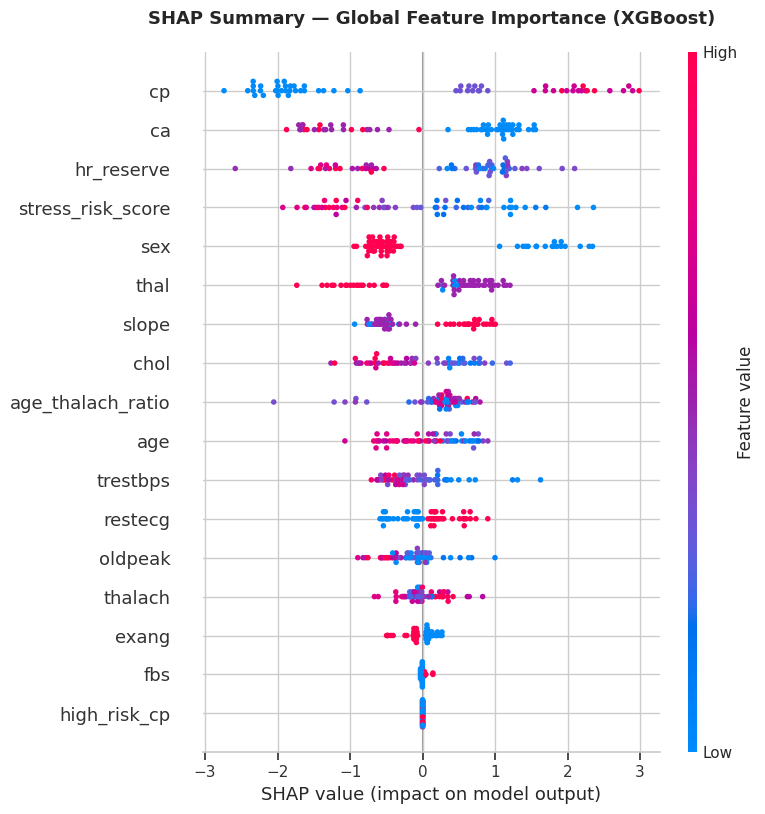

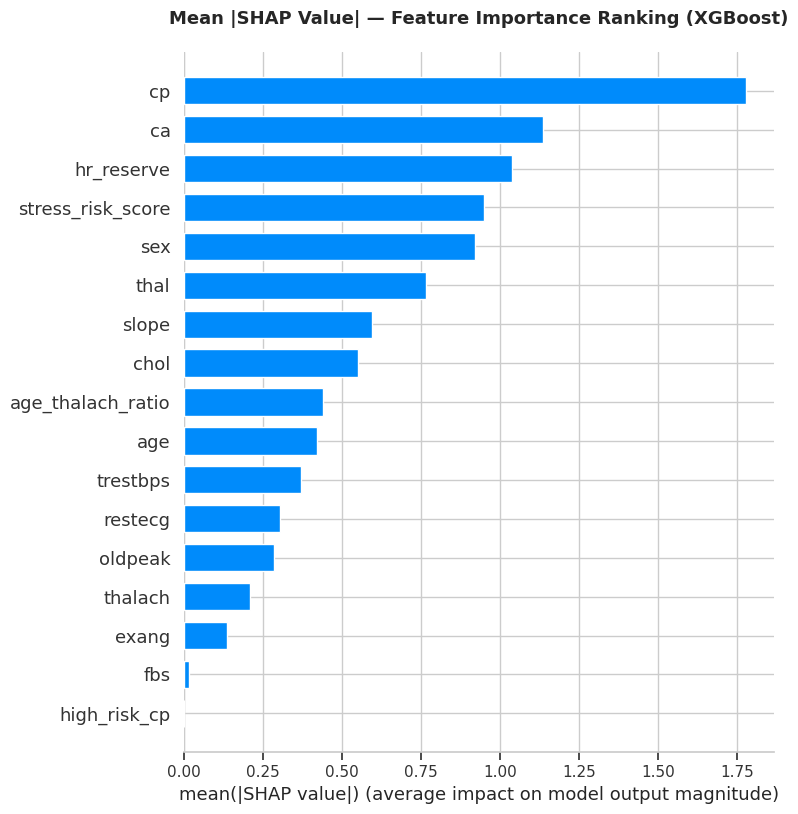

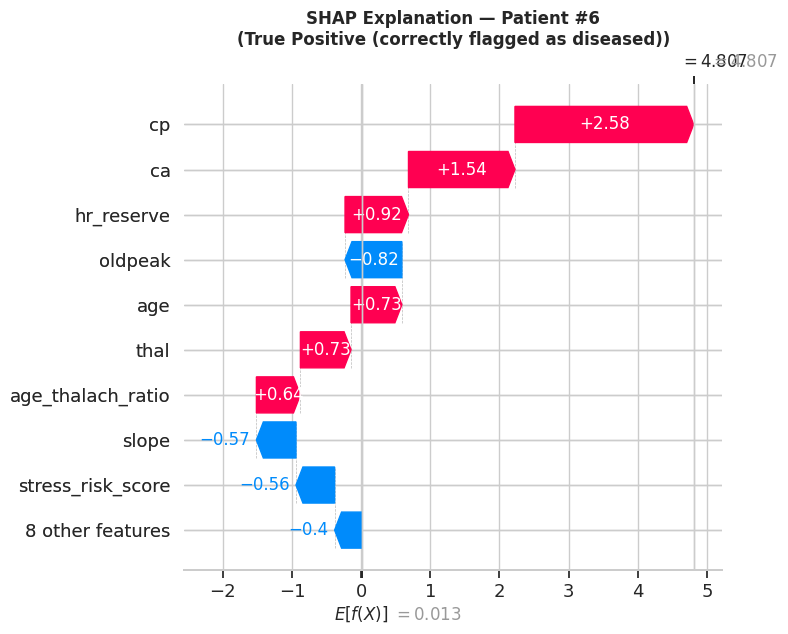

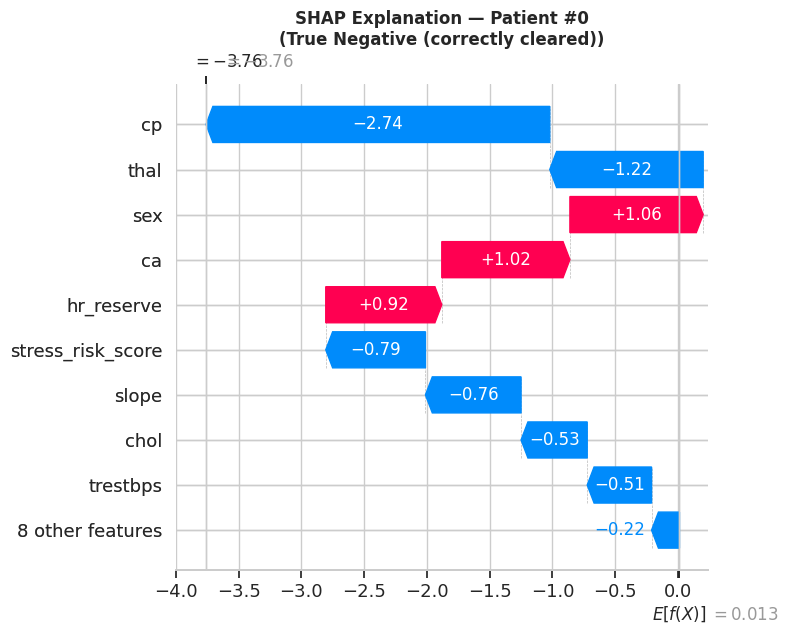


Top 5 features by mean |SHAP value|:
          feature  mean_abs_shap
               cp       1.778117
               ca       1.134971
       hr_reserve       1.036763
stress_risk_score       0.951109
              sex       0.920492


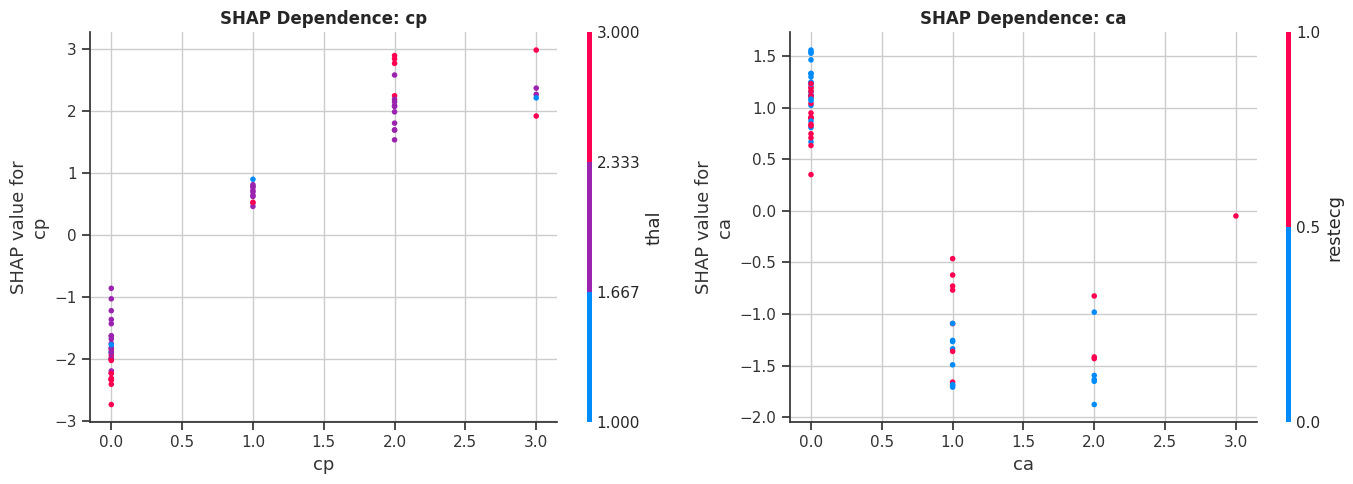


✅ SHAP explainability analysis complete.

 Cross-check: compare this SHAP ranking to the mutual-information ranking
   from Chunk 4 — do 'stress_risk_score' and 'high_risk_cp' remain top-ranked
   under a completely different attribution method? Convergence between the
   two strengthens confidence that these are genuinely important, not artifacts
   of one particular technique.


In [8]:
import shap

shap.initjs()

print(f"Generating SHAP explanations for: {best_model_name}")

tree_based = best_model_name in ["Random Forest", "XGBoost"]

if tree_based:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_final)
    if isinstance(shap_values, list):
        shap_values = shap_values[1]
else:
    background = shap.sample(X_train_final, 50, random_state=RANDOM_STATE)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values_full = explainer.shap_values(X_test_final, nsamples=100)
    shap_values = shap_values_full[1]

print("✅ SHAP values computed.")

plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_final, show=False)
plt.title(f"SHAP Summary — Global Feature Importance ({best_model_name})",
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

plt.figure(figsize=(9, 7))
shap.summary_plot(shap_values, X_test_final, plot_type="bar", show=False)
plt.title(f"Mean |SHAP Value| — Feature Importance Ranking ({best_model_name})",
          fontweight='bold', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()

y_test_reset = y_test_final.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred_test).reset_index(drop=True)

tp_idx = y_test_reset[(y_test_reset == 1) & (y_pred_reset == 1)].index[0]
tn_idx = y_test_reset[(y_test_reset == 0) & (y_pred_reset == 0)].index[0]

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = expected_value[1] if len(np.atleast_1d(expected_value)) > 1 else expected_value

for label, idx in [("True Positive (correctly flagged as diseased)", tp_idx),
                    ("True Negative (correctly cleared)", tn_idx)]:
    plt.figure(figsize=(10, 6))
    shap.plots._waterfall.waterfall_legacy(
        expected_value, shap_values[idx],
        feature_names=X_test_final.columns.tolist(),
        max_display=10, show=False
    )
    plt.title(f"SHAP Explanation — Patient #{idx}\n({label})", fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}shap_waterfall_{idx}.png", dpi=150, bbox_inches='tight')
    plt.show()


mean_abs_shap = pd.DataFrame({
    "feature": X_test_final.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print("\nTop 5 features by mean |SHAP value|:")
print(mean_abs_shap.head(5).to_string(index=False))

top2_features = mean_abs_shap["feature"].iloc[:2].tolist()
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, feat in enumerate(top2_features):
    shap.dependence_plot(feat, shap_values, X_test_final, ax=axes[i], show=False)
    axes[i].set_title(f"SHAP Dependence: {feat}", fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}shap_dependence.png", dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap.to_csv(f"{CONFIG['output_dir']}shap_importance.csv", index=False)

print("\n✅ SHAP explainability analysis complete.")
print(f"\n Cross-check: compare this SHAP ranking to the mutual-information ranking")
print(f"   from Chunk 4 — do 'stress_risk_score' and 'high_risk_cp' remain top-ranked")
print(f"   under a completely different attribution method? Convergence between the")
print(f"   two strengthens confidence that these are genuinely important, not artifacts")
print(f"   of one particular technique.")



SUBGROUP AUDIT — XGBoost performance across demographic groups


    group   value  n  accuracy  precision  recall     f1  roc_auc
      sex  Female 18    0.7778     0.8462  0.8462 0.8462   0.7846
      sex    Male 43    0.7209     0.7000  0.7000 0.7000   0.8478
age_group Younger 30    0.8333     0.9000  0.8571 0.8780   0.9312
age_group   Older 31    0.6452     0.5385  0.5833 0.5600   0.7412


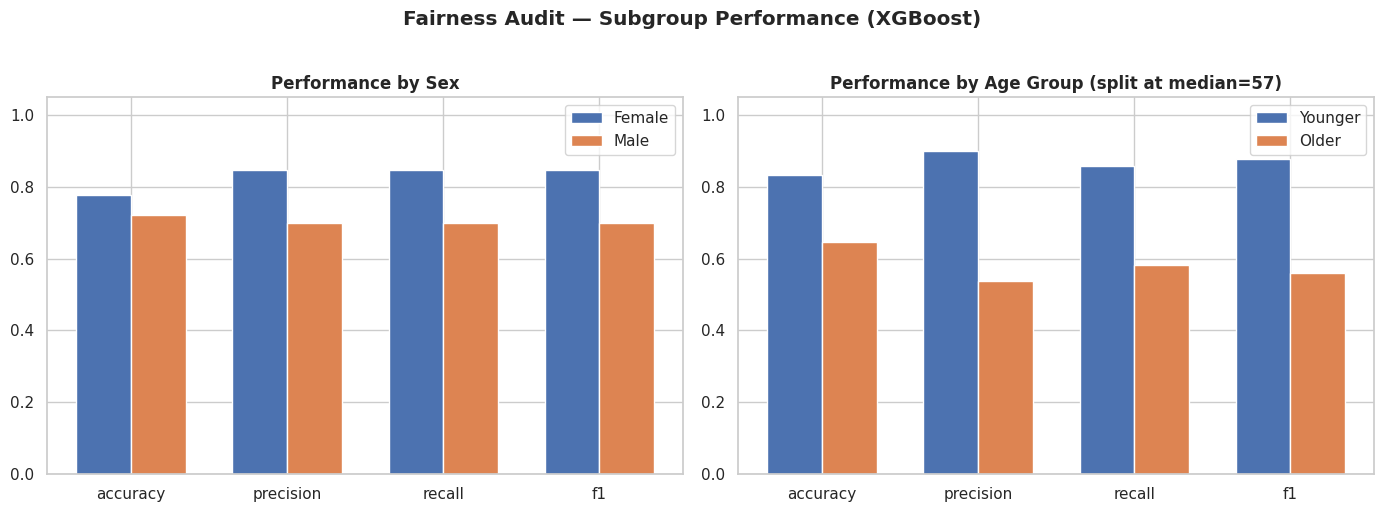



DISPARITY SUMMARY



SEX: Female vs Male
  Recall gap: 0.1462  |  F1 gap: 0.1462
  ✅ Comparable performance

AGE_GROUP: Younger vs Older
  Recall gap: 0.2738  |  F1 gap: 0.3180
  Notable disparity — worth discussing limitations

✅ Fairness audit complete. Results saved to outputs/

 Note: with only ~61 test patients split into subgroups, these subgroup
   sample sizes are small (n≈15-30 per group), so treat gaps as directional
   signals for discussion, not statistically confirmed disparities. A larger
   held-out set would be needed to draw firm conclusions — an explicit
   limitation worth stating in your writeup.


In [9]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_test_orig = X_test_fe.reset_index(drop=True)
y_test_reset = y_test_final.reset_index(drop=True)
y_pred_reset = pd.Series(y_pred_test).reset_index(drop=True)
y_proba_reset = pd.Series(y_proba_test).reset_index(drop=True)

results_df = X_test_orig.copy()
results_df["y_true"] = y_test_reset
results_df["y_pred"] = y_pred_reset
results_df["y_proba"] = y_proba_reset

def subgroup_metrics(df_subset, group_name, group_val):
    yt, yp, ypr = df_subset["y_true"], df_subset["y_pred"], df_subset["y_proba"]
    if len(yt.unique()) < 2:
        auc = np.nan
    else:
        auc = roc_auc_score(yt, ypr)
    return {
        "group": group_name, "value": group_val, "n": len(df_subset),
        "accuracy": accuracy_score(yt, yp),
        "precision": precision_score(yt, yp, zero_division=0),
        "recall": recall_score(yt, yp, zero_division=0),
        "f1": f1_score(yt, yp, zero_division=0),
        "roc_auc": auc
    }

print("\n")
print(f"SUBGROUP AUDIT — {best_model_name} performance across demographic groups")
print("\n")

fairness_rows = []

for sex_val, sex_label in [(0, "Female"), (1, "Male")]:
    subset = results_df[results_df["sex"] == sex_val]
    if len(subset) > 0:
        fairness_rows.append(subgroup_metrics(subset, "sex", sex_label))

age_median = results_df["age"].median()
results_df["age_group"] = np.where(results_df["age"] < age_median, "Younger", "Older")
for age_grp in ["Younger", "Older"]:
    subset = results_df[results_df["age_group"] == age_grp]
    if len(subset) > 0:
        fairness_rows.append(subgroup_metrics(subset, "age_group", age_grp))

fairness_df = pd.DataFrame(fairness_rows)
print(fairness_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_data = fairness_df[fairness_df["group"] == "sex"]
metrics_plot = ["accuracy", "precision", "recall", "f1"]
x = np.arange(len(metrics_plot))
width = 0.35
for i, (_, row) in enumerate(sex_data.iterrows()):
    axes[0].bar(x + i * width, [row[m] for m in metrics_plot], width, label=row["value"])
axes[0].set_xticks(x + width / 2)
axes[0].set_xticklabels(metrics_plot)
axes[0].set_title("Performance by Sex", fontweight='bold')
axes[0].set_ylim(0, 1.05)
axes[0].legend()

age_data = fairness_df[fairness_df["group"] == "age_group"]
for i, (_, row) in enumerate(age_data.iterrows()):
    axes[1].bar(x + i * width, [row[m] for m in metrics_plot], width, label=row["value"])
axes[1].set_xticks(x + width / 2)
axes[1].set_xticklabels(metrics_plot)
axes[1].set_title(f"Performance by Age Group (split at median={age_median:.0f})", fontweight='bold')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.suptitle(f"Fairness Audit — Subgroup Performance ({best_model_name})", fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}fairness_audit.png", dpi=150, bbox_inches='tight')
plt.show()

print("\n")
print("DISPARITY SUMMARY")
print("\n")

for group_col in ["sex", "age_group"]:
    sub = fairness_df[fairness_df["group"] == group_col]
    if len(sub) == 2:
        gap_recall = abs(sub["recall"].iloc[0] - sub["recall"].iloc[1])
        gap_f1 = abs(sub["f1"].iloc[0] - sub["f1"].iloc[1])
        print(f"\n{group_col.upper()}: {sub['value'].iloc[0]} vs {sub['value'].iloc[1]}")
        print(f"  Recall gap: {gap_recall:.4f}  |  F1 gap: {gap_f1:.4f}")
        flag = "Notable disparity — worth discussing limitations" if gap_recall > 0.15 else "✅ Comparable performance"
        print(f"  {flag}")

fairness_df.to_csv(f"{CONFIG['output_dir']}fairness_audit.csv", index=False)
print("\n✅ Fairness audit complete. Results saved to outputs/")
print("\n Note: with only ~61 test patients split into subgroups, these subgroup")
print("   sample sizes are small (n≈15-30 per group), so treat gaps as directional")
print("   signals for discussion, not statistically confirmed disparities. A larger")
print("   held-out set would be needed to draw firm conclusions — an explicit")
print("   limitation worth stating in your writeup.")

In [10]:
import json

inference_bundle = {
    "model_name": best_model_name,
    "model": best_model,
    "scaler": scaler_fe,
    "numeric_features_to_scale": NUMERIC_FEATURES + ["age_thalach_ratio", "hr_reserve", "stress_risk_score"],
    "all_feature_columns": X_train_final.columns.tolist(),
    "feature_dict": FEATURE_DICT,
    "training_date": datetime.now().strftime("%Y-%m-%d"),
    "test_set_metrics": test_metrics,
    "cv_metrics": {
        "f1_mean": float(cv_summary_df.iloc[0]["f1"]),
        "f1_ci95": float(cv_summary_df.iloc[0]["f1_ci95"]),
        "roc_auc_mean": float(cv_summary_df.iloc[0]["roc_auc"])
    }
}

joblib.dump(inference_bundle, f"{CONFIG['model_dir']}heart_disease_inference_bundle.pkl")
print(f"✅ Complete inference bundle saved: {CONFIG['model_dir']}heart_disease_inference_bundle.pkl")

def predict_heart_disease_risk(patient_dict, bundle=inference_bundle, explainer=explainer, verbose=True):
    """
    Predict heart disease risk for a single patient from raw clinical inputs.

    Parameters
    ----------
    patient_dict : dict
        Raw feature values, e.g.:
        {"age": 58, "sex": 1, "cp": 0, "trestbps": 145, "chol": 233,
         "fbs": 1, "restecg": 0, "thalach": 150, "exang": 1,
         "oldpeak": 2.3, "slope": 1, "ca": 0, "thal": 2}

    Returns
    -------
    dict with prediction, probability, risk category, and top SHAP factors
    """
    df_input = pd.DataFrame([patient_dict])

    df_input["age_thalach_ratio"] = df_input["age"] / df_input["thalach"]
    df_input["hr_reserve"] = (220 - df_input["age"]) - df_input["thalach"]
    df_input["stress_risk_score"] = (
        df_input["oldpeak"] * 0.4 + df_input["exang"] * 0.3 + df_input["ca"] * 0.3
    )
    df_input["high_risk_cp"] = (df_input["cp"] == 0).astype(int)

    df_input = df_input[bundle["all_feature_columns"]]

    df_scaled = df_input.copy()
    df_scaled[bundle["numeric_features_to_scale"]] = bundle["scaler"].transform(
        df_input[bundle["numeric_features_to_scale"]]
    )

    pred = bundle["model"].predict(df_scaled)[0]
    proba = bundle["model"].predict_proba(df_scaled)[0, 1]

    if proba < 0.3:
        risk_category = "Low"
    elif proba < 0.6:
        risk_category = "Moderate"
    else:
        risk_category = "High"

    sv = explainer.shap_values(df_scaled)
    if isinstance(sv, list):
        sv = sv[1]
    contrib = pd.Series(sv[0], index=df_scaled.columns).sort_values(key=abs, ascending=False)
    top_factors = contrib.head(3)

    result = {
        "prediction": "Disease Likely" if pred == 1 else "Disease Unlikely",
        "probability": round(float(proba), 4),
        "risk_category": risk_category,
        "top_contributing_factors": {k: round(float(v), 4) for k, v in top_factors.items()}
    }

    if verbose:
        print(f" Prediction: {result['prediction']}")
        print(f"   Probability: {result['probability']:.1%}")
        print(f"   Risk category: {result['risk_category']}")
        print(f"   Top contributing factors (SHAP):")
        for feat, val in result["top_contributing_factors"].items():
            direction = "↑ increases risk" if val > 0 else "↓ decreases risk"
            print(f"     - {feat}: {val:+.4f}  ({direction})")

    return result

sample_patient = X_test_orig.iloc[0][["age","sex","cp","trestbps","chol","fbs",
                                        "restecg","thalach","exang","oldpeak",
                                        "slope","ca","thal"]].to_dict()

print("\n")
print("DEMO: Predicting on a real held-out patient")
print("\n")
print(f"Input: {sample_patient}")
print(f"Actual outcome: {'Disease' if y_test_reset.iloc[0]==1 else 'No Disease'}\n")

result = predict_heart_disease_risk(sample_patient)

metadata = {k: v for k, v in inference_bundle.items() if k not in ["model", "scaler"]}
with open(f"{CONFIG['output_dir']}model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"\n✅ Inference pipeline complete.")
print(f"   Model bundle: {CONFIG['model_dir']}heart_disease_inference_bundle.pkl")
print(f"   Metadata:     {CONFIG['output_dir']}model_metadata.json")

✅ Complete inference bundle saved: models/heart_disease_inference_bundle.pkl


DEMO: Predicting on a real held-out patient


Input: {'age': 61.0, 'sex': 0.0, 'cp': 0.0, 'trestbps': 145.0, 'chol': 307.0, 'fbs': 0.0, 'restecg': 0.0, 'thalach': 146.0, 'exang': 1.0, 'oldpeak': 1.0, 'slope': 1.0, 'ca': 0.0, 'thal': 3.0}
Actual outcome: No Disease

 Prediction: Disease Unlikely
   Probability: 2.3%
   Risk category: Low
   Top contributing factors (SHAP):
     - cp: -2.7389  (↓ decreases risk)
     - thal: -1.2225  (↓ decreases risk)
     - sex: +1.0619  (↑ increases risk)

✅ Inference pipeline complete.
   Model bundle: models/heart_disease_inference_bundle.pkl
   Metadata:     outputs/model_metadata.json


In [11]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

st.set_page_config(page_title="Explainable Heart Disease Risk Prediction",
                    page_icon="🫀", layout="wide")

@st.cache_resource
def load_bundle():
    bundle = joblib.load("models/heart_disease_inference_bundle.pkl")
    explainer = shap.TreeExplainer(bundle["model"])
    return bundle, explainer

bundle, explainer = load_bundle()

st.title("🫀 Explainable Heart Disease Risk Prediction")
st.markdown(f"""
An interpretable machine learning system for cardiovascular risk assessment,
built on the Cleveland Heart Disease dataset (UCI). Model: **{bundle['model_name']}**
(cross-validated F1 = {bundle['cv_metrics']['f1_mean']:.3f} ± {bundle['cv_metrics']['f1_ci95']:.3f}).

Every prediction is accompanied by a SHAP-based explanation showing *why*
the model reached its conclusion — not just a black-box output.
""")

st.divider()

col1, col2, col3 = st.columns(3)

with col1:
    age = st.slider("Age", 25, 80, 55)
    sex = st.selectbox("Sex", options=[("Male", 1), ("Female", 0)], format_func=lambda x: x[0])[1]
    cp = st.selectbox("Chest Pain Type", options=[
        ("Typical Angina", 0), ("Atypical Angina", 1),
        ("Non-anginal Pain", 2), ("Asymptomatic", 3)], format_func=lambda x: x[0])[1]
    trestbps = st.slider("Resting Blood Pressure (mm Hg)", 90, 200, 130)

with col2:
    chol = st.slider("Serum Cholesterol (mg/dl)", 120, 570, 240)
    fbs = st.selectbox("Fasting Blood Sugar > 120 mg/dl", options=[("No", 0), ("Yes", 1)], format_func=lambda x: x[0])[1]
    restecg = st.selectbox("Resting ECG", options=[("Normal", 0), ("ST-T abnormality", 1), ("LV hypertrophy", 2)], format_func=lambda x: x[0])[1]
    thalach = st.slider("Max Heart Rate Achieved", 70, 210, 150)

with col3:
    exang = st.selectbox("Exercise-Induced Angina", options=[("No", 0), ("Yes", 1)], format_func=lambda x: x[0])[1]
    oldpeak = st.slider("ST Depression (oldpeak)", 0.0, 6.5, 1.0, step=0.1)
    slope = st.selectbox("Slope of Peak Exercise ST", options=[("Upsloping", 0), ("Flat", 1), ("Downsloping", 2)], format_func=lambda x: x[0])[1]
    ca = st.selectbox("Major Vessels Colored (fluoroscopy)", options=[0, 1, 2, 3, 4])
    thal = st.selectbox("Thalassemia", options=[("Normal", 1), ("Fixed Defect", 2), ("Reversible Defect", 3)], format_func=lambda x: x[0])[1]

st.divider()

if st.button("Assess Risk", type="primary", use_container_width=True):

    patient = {"age": age, "sex": sex, "cp": cp, "trestbps": trestbps, "chol": chol,
               "fbs": fbs, "restecg": restecg, "thalach": thalach, "exang": exang,
               "oldpeak": oldpeak, "slope": slope, "ca": ca, "thal": thal}

    df_input = pd.DataFrame([patient])
    df_input["age_thalach_ratio"] = df_input["age"] / df_input["thalach"]
    df_input["hr_reserve"] = (220 - df_input["age"]) - df_input["thalach"]
    df_input["stress_risk_score"] = df_input["oldpeak"]*0.4 + df_input["exang"]*0.3 + df_input["ca"]*0.3
    df_input["high_risk_cp"] = (df_input["cp"] == 0).astype(int)
    df_input = df_input[bundle["all_feature_columns"]]

    df_scaled = df_input.copy()
    df_scaled[bundle["numeric_features_to_scale"]] = bundle["scaler"].transform(
        df_input[bundle["numeric_features_to_scale"]])

    pred = bundle["model"].predict(df_scaled)[0]
    proba = bundle["model"].predict_proba(df_scaled)[0, 1]
    risk = "Low" if proba < 0.3 else ("Moderate" if proba < 0.6 else "High")

    res_col1, res_col2 = st.columns([1, 2])

    with res_col1:
        color = {"Low": "green", "Moderate": "orange", "High": "red"}[risk]
        st.markdown("### Prediction")
        st.markdown(f"**{'Disease Likely' if pred==1 else '✅ Disease Unlikely'}**")
        st.metric("Estimated Probability", f"{proba:.1%}")
        st.markdown(f"Risk category: :{color}[**{risk}**]")

    with res_col2:
        st.markdown("### Why this prediction? (SHAP explanation)")
        sv = explainer.shap_values(df_scaled)
        if isinstance(sv, list):
            sv = sv[1]

        fig, ax = plt.subplots(figsize=(8, 4))
        shap.plots._waterfall.waterfall_legacy(
            explainer.expected_value if not isinstance(explainer.expected_value, (list, np.ndarray))
            else explainer.expected_value[1],
            sv[0], feature_names=df_scaled.columns.tolist(), max_display=8, show=False)
        st.pyplot(fig)

    st.info("**Disclaimer:** This tool is a machine learning demonstration built for "
            "educational/research purposes and is NOT a substitute for professional "
            "medical diagnosis. Consult a qualified healthcare provider for any "
            "health concerns.")

st.divider()
st.caption(f"Model trained on {bundle['training_date']} | Test set F1: {bundle['test_set_metrics']['f1']:.3f}")

Writing app.py




ERROR BREAKDOWN


Correct predictions:  45 / 61
False Negatives (missed disease): 8  clinically the costlier error
False Positives (unnecessary flag): 8

Average confidence on errors (distance from 0.5 threshold): 0.385
(Lower = mostly 'close calls'; higher = model was confidently wrong)


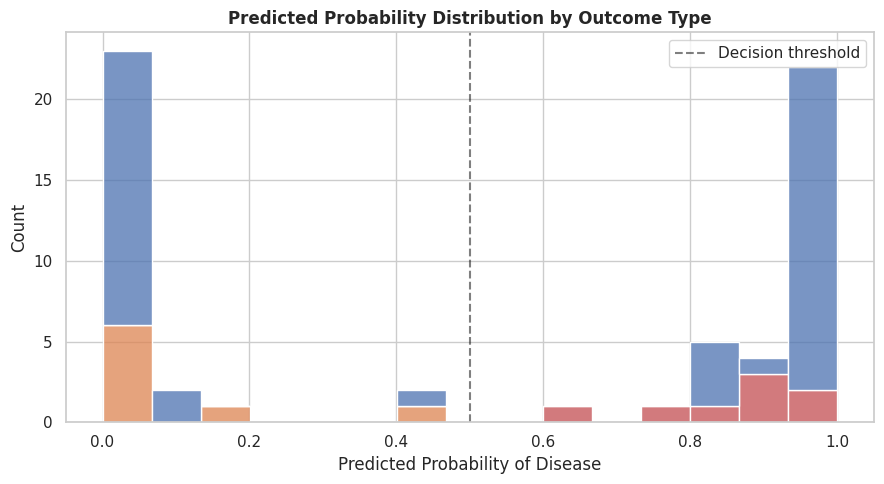

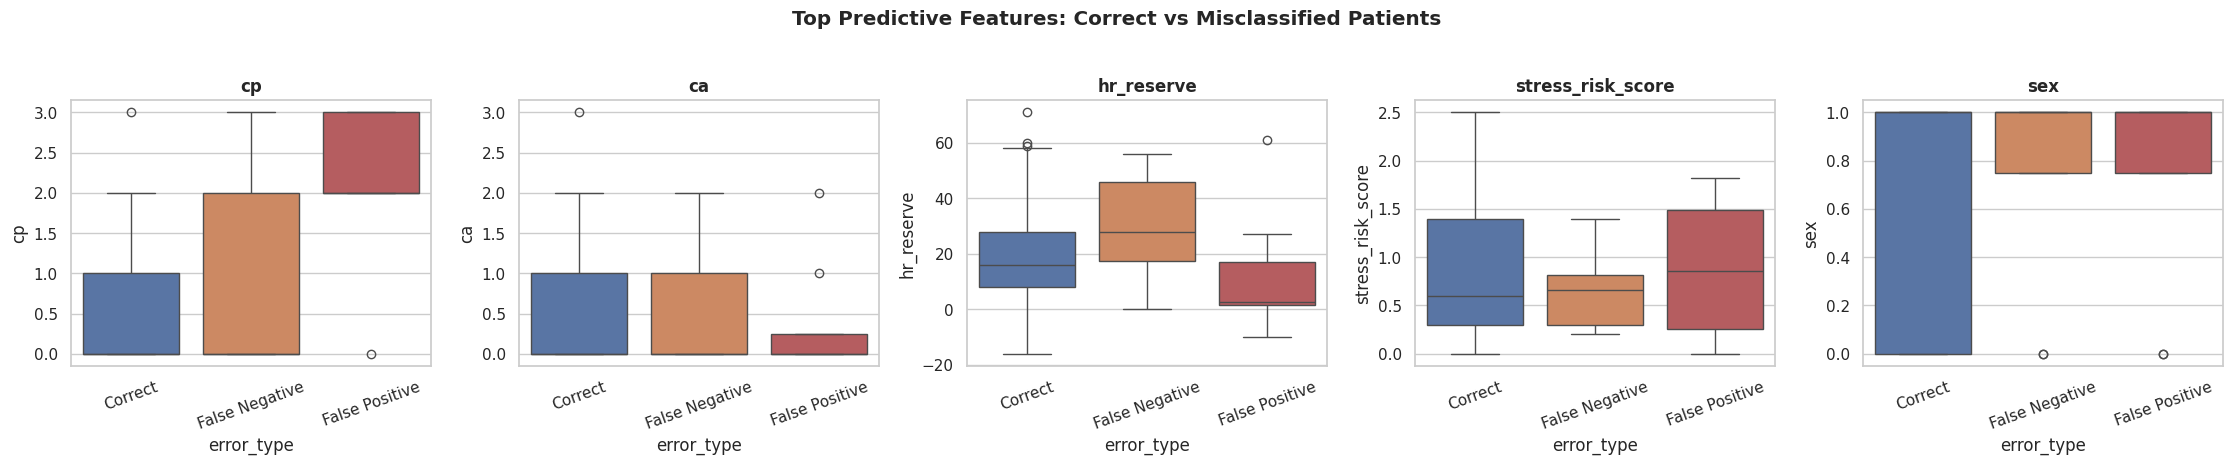



MOST CONFIDENT MISCLASSIFICATION — Patient #4


Error type: False Positive
True label: No Disease  |  Predicted: Disease  (confidence: 99.9%)


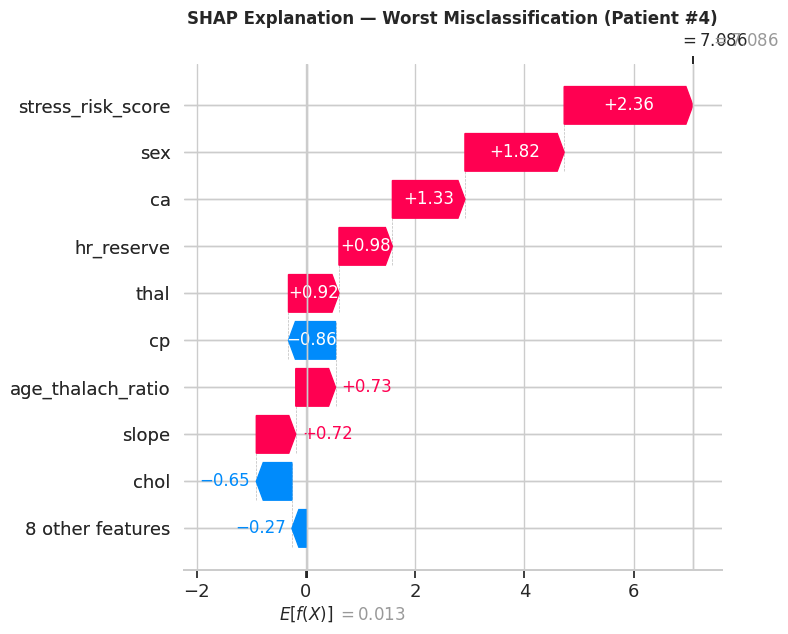


 Interpretation: examine which features pushed this prediction the wrong
   way. This often reveals either (a) a genuinely atypical/borderline patient
   presentation, or (b) a feature interaction the model hasn't learned well —
   both are legitimate, reportable limitations rather than random noise.

 Error analysis complete. Saved to outputs/error_analysis.csv


In [13]:
error_df = X_test_orig.copy()
error_df["y_true"] = y_test_reset
error_df["y_pred"] = y_pred_reset
error_df["y_proba"] = y_proba_reset
error_df["error_type"] = np.select(
    [
        (error_df["y_true"] == 1) & (error_df["y_pred"] == 0),
        (error_df["y_true"] == 0) & (error_df["y_pred"] == 1)
    ],
    ["False Negative", "False Positive"],
    default="Correct"
)

n_fn = (error_df["error_type"] == "False Negative").sum()
n_fp = (error_df["error_type"] == "False Positive").sum()
n_correct = (error_df["error_type"] == "Correct").sum()

print("\n")
print("ERROR BREAKDOWN")
print("\n")
print(f"Correct predictions:  {n_correct} / {len(error_df)}")
print(f"False Negatives (missed disease): {n_fn}  clinically the costlier error")
print(f"False Positives (unnecessary flag): {n_fp}")

errors_only = error_df[error_df["error_type"] != "Correct"].copy()
errors_only["distance_from_threshold"] = (errors_only["y_proba"] - 0.5).abs()

print(f"\nAverage confidence on errors (distance from 0.5 threshold): "
      f"{errors_only['distance_from_threshold'].mean():.3f}")
print("(Lower = mostly 'close calls'; higher = model was confidently wrong)")

plt.figure(figsize=(9, 5))
sns.histplot(data=error_df, x="y_proba", hue="error_type",
             bins=15, multiple="stack",
             palette={"Correct": "#4C72B0", "False Negative": "#DD8452", "False Positive": "#C44E52"})
plt.axvline(0.5, color='black', linestyle='--', alpha=0.5, label="Decision threshold")
plt.title("Predicted Probability Distribution by Outcome Type", fontweight='bold')
plt.xlabel("Predicted Probability of Disease")
plt.legend()
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}error_confidence_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

compare_features = mean_abs_shap["feature"].iloc[:5].tolist()
compare_features = [f for f in compare_features if f in error_df.columns]

fig, axes = plt.subplots(1, len(compare_features), figsize=(4.5 * len(compare_features), 4.5))
if len(compare_features) == 1:
    axes = [axes]

for i, feat in enumerate(compare_features):
    sns.boxplot(data=error_df, x="error_type", y=feat, ax=axes[i],
                order=["Correct", "False Negative", "False Positive"],
                palette=["#4C72B0", "#DD8452", "#C44E52"])
    axes[i].set_title(feat, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=20)

plt.suptitle("Top Predictive Features: Correct vs Misclassified Patients", fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}error_feature_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

if len(errors_only) > 0:
    worst_idx = errors_only["distance_from_threshold"].idxmax()
    worst_case = error_df.loc[worst_idx]

    print("\n")
    print(f"MOST CONFIDENT MISCLASSIFICATION — Patient #{worst_idx}")
    print("\n")
    print(f"Error type: {worst_case['error_type']}")
    print(f"True label: {'Disease' if worst_case['y_true']==1 else 'No Disease'}  |  "
          f"Predicted: {'Disease' if worst_case['y_pred']==1 else 'No Disease'}  "
          f"(confidence: {worst_case['y_proba']:.1%})")

    plt.figure(figsize=(10, 6))
    shap.plots._waterfall.waterfall_legacy(
        expected_value, shap_values[worst_idx],
        feature_names=X_test_final.columns.tolist(),
        max_display=10, show=False
    )
    plt.title(f"SHAP Explanation — Worst Misclassification (Patient #{worst_idx})",
              fontweight='bold', fontsize=12)
    plt.tight_layout()
    plt.savefig(f"{CONFIG['figures_dir']}shap_worst_error.png", dpi=150, bbox_inches='tight')
    plt.show()

    print("\n Interpretation: examine which features pushed this prediction the wrong")
    print("   way. This often reveals either (a) a genuinely atypical/borderline patient")
    print("   presentation, or (b) a feature interaction the model hasn't learned well —")
    print("   both are legitimate, reportable limitations rather than random noise.")

error_df.to_csv(f"{CONFIG['output_dir']}error_analysis.csv", index=False)
print("\n Error analysis complete. Saved to outputs/error_analysis.csv")



THRESHOLD OPTIMIZATION RESULTS



Default threshold (0.50):
  Precision: 0.758  Recall: 0.758  F1: 0.758  FN: 8  FP: 8

Best F1 threshold (0.11) — balances precision & recall equally:
  Precision: 0.750  Recall: 0.818  F1: 0.783  FN: 6  FP: 9

Best F2 threshold (0.06) — prioritizes recall (minimizing missed disease):
  Precision: 0.718  Recall: 0.848  F2: 0.819  FN: 5  FP: 11


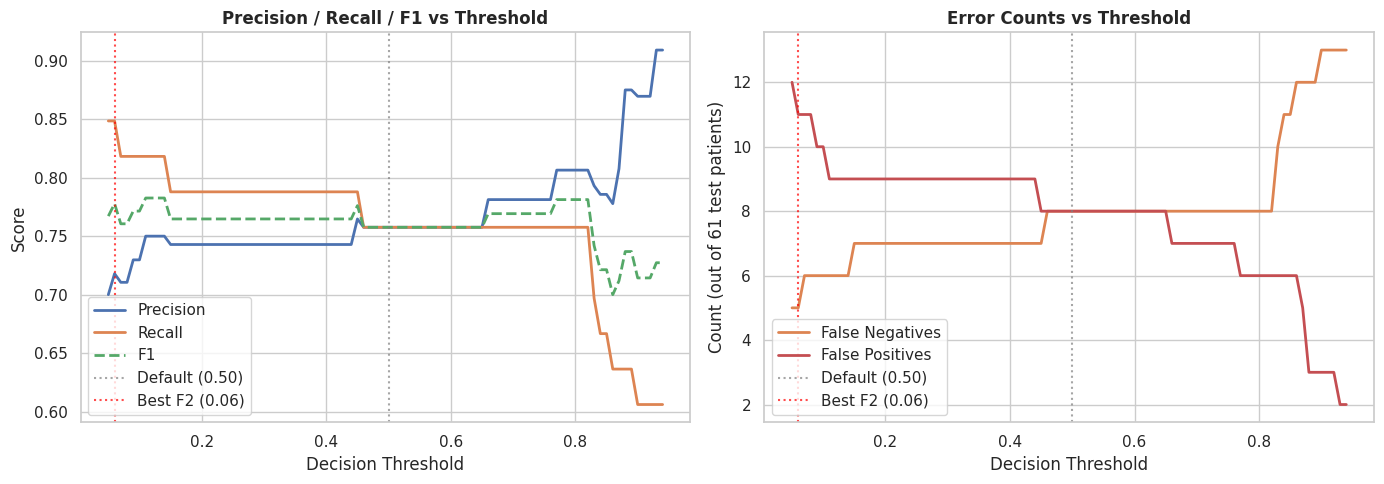



RECOMMENDATION


For a clinical screening context, we recommend threshold = 0.06
(instead of the default 0.50), because it reduces False Negatives from 8 to 5 at the cost of +3 additional False Positives.

Rationale: in screening, a False Positive leads to a follow-up test (low cost),
while a False Negative means a real case of heart disease goes undetected
(high cost). This asymmetry justifies shifting the threshold below 0.5.

✅ Threshold optimization complete. Saved to outputs/threshold_optimization.csv


In [14]:
from sklearn.metrics import precision_recall_curve, f1_score, fbeta_score, confusion_matrix

thresholds = np.arange(0.05, 0.95, 0.01)
threshold_results = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test_final, y_pred_t).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    # F2 score weights recall higher than precision (beta=2) — appropriate
    # when missing a positive case (disease) is worse than a false alarm
    f2 = fbeta_score(y_test_final, y_pred_t, beta=2, zero_division=0)
    threshold_results.append({
        "threshold": t, "precision": precision, "recall": recall,
        "f1": f1, "f2": f2, "false_negatives": fn, "false_positives": fp
    })

thresh_df = pd.DataFrame(threshold_results)

best_f1_row = thresh_df.loc[thresh_df["f1"].idxmax()]
best_f2_row = thresh_df.loc[thresh_df["f2"].idxmax()]
default_row = thresh_df.iloc[(thresh_df["threshold"] - 0.50).abs().idxmin()]

print("\n")
print("THRESHOLD OPTIMIZATION RESULTS")
print("\n")

print(f"\nDefault threshold (0.50):")
print(f"  Precision: {default_row['precision']:.3f}  Recall: {default_row['recall']:.3f}  "
      f"F1: {default_row['f1']:.3f}  FN: {default_row['false_negatives']:.0f}  FP: {default_row['false_positives']:.0f}")

print(f"\nBest F1 threshold ({best_f1_row['threshold']:.2f}) — balances precision & recall equally:")
print(f"  Precision: {best_f1_row['precision']:.3f}  Recall: {best_f1_row['recall']:.3f}  "
      f"F1: {best_f1_row['f1']:.3f}  FN: {best_f1_row['false_negatives']:.0f}  FP: {best_f1_row['false_positives']:.0f}")

print(f"\nBest F2 threshold ({best_f2_row['threshold']:.2f}) — prioritizes recall "
      f"(minimizing missed disease):")
print(f"  Precision: {best_f2_row['precision']:.3f}  Recall: {best_f2_row['recall']:.3f}  "
      f"F2: {best_f2_row['f2']:.3f}  FN: {best_f2_row['false_negatives']:.0f}  FP: {best_f2_row['false_positives']:.0f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", linewidth=2)
axes[0].plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", linewidth=2)
axes[0].plot(thresh_df["threshold"], thresh_df["f1"], label="F1", linewidth=2, linestyle="--")
axes[0].axvline(0.5, color='gray', linestyle=':', alpha=0.7, label="Default (0.50)")
axes[0].axvline(best_f2_row["threshold"], color='red', linestyle=':', alpha=0.7,
                label=f"Best F2 ({best_f2_row['threshold']:.2f})")
axes[0].set_xlabel("Decision Threshold")
axes[0].set_ylabel("Score")
axes[0].set_title("Precision / Recall / F1 vs Threshold", fontweight='bold')
axes[0].legend()

axes[1].plot(thresh_df["threshold"], thresh_df["false_negatives"], label="False Negatives", color="#DD8452", linewidth=2)
axes[1].plot(thresh_df["threshold"], thresh_df["false_positives"], label="False Positives", color="#C44E52", linewidth=2)
axes[1].axvline(0.5, color='gray', linestyle=':', alpha=0.7, label="Default (0.50)")
axes[1].axvline(best_f2_row["threshold"], color='red', linestyle=':', alpha=0.7,
                label=f"Best F2 ({best_f2_row['threshold']:.2f})")
axes[1].set_xlabel("Decision Threshold")
axes[1].set_ylabel("Count (out of 61 test patients)")
axes[1].set_title("Error Counts vs Threshold", fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig(f"{CONFIG['figures_dir']}threshold_optimization.png", dpi=150, bbox_inches='tight')
plt.show()

recommended_threshold = best_f2_row["threshold"]
fp_diff = best_f2_row["false_positives"] - default_row["false_positives"]

print("\n")
print("RECOMMENDATION")
print("\n")
print(f"For a clinical screening context, we recommend threshold = {recommended_threshold:.2f}")
print(f"(instead of the default 0.50), because it reduces False Negatives from "
      f"{default_row['false_negatives']:.0f} to {best_f2_row['false_negatives']:.0f} "
      f"at the cost of {fp_diff:+.0f} additional False Positives.")
print(f"\nRationale: in screening, a False Positive leads to a follow-up test (low cost),")
print(f"while a False Negative means a real case of heart disease goes undetected")
print(f"(high cost). This asymmetry justifies shifting the threshold below 0.5.")

thresh_df.to_csv(f"{CONFIG['output_dir']}threshold_optimization.csv", index=False)
print("\n✅ Threshold optimization complete. Saved to outputs/threshold_optimization.csv")